# Predicting Mortgage Prepayment with Machine Learning (Freddie Mac sample data, 2017-2020)

Re-implementation of *"Predicting Mortgage Backed Securities Prepayment Using Machine Learning Methods"* (Guo, Boccio, Cameron).

**Pipeline**: origination + monthly performance files -> random sample of loans per origination quarter -> loan-month panel -> macro features -> prepayment target -> one-hot / scaling -> 60/20/20 split -> Logistic (base / L1 / L2), SVM (RBF / sigmoid / poly), GDA (linear / quadratic), feed-forward NN -> Table-1 style comparison.

**To use more or fewer years, edit only `YEARS` in the config cell** (see the last cell for other knobs).

Two deliberate options that differ from a naive reading of the paper (both default to the paper's behaviour):
* `TARGET_MODE`: `"same_month"` = paper (features and prepayment event in the *same* month). In this mode `current_UPB` is ~0 in the month the loan terminates, so it nearly gives away the label (this is likely why the paper reports ~99.9% accuracy). `"next_month"` predicts prepayment in month *t+1* from information at month *t*, which is the honest forecasting version.
* `SPLIT_BY`: `"row"` = paper (random rows, the same loan can appear in train and test). `"loan"` keeps every loan entirely in one split.

In [3]:
import sys, os, time, warnings, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, precision_score, f1_score)
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Python :", sys.version.split()[0])
print("pandas :", pd.__version__, "| numpy:", np.__version__, "| sklearn:", sklearn.__version__)
print("torch  :", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

Python : 3.13.0
pandas : 3.0.6 | numpy: 2.5.3 | sklearn: 1.9.1
torch  : 2.14.1+cu132 | CUDA available: True
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Configuration

In [ ]:
# ----------------------------- DATA SELECTION -----------------------------
YEARS = list(range(2017, 2021))     # 2017..2020 -> change this to use more/fewer years
LOANS_PER_QUARTER = 100            # loans randomly sampled per origination quarter (paper used 100)
SEED = 42

# ----------------------------- TARGET / SPLIT -----------------------------
TARGET_MODE = "same_month"          # "same_month" (paper) or "next_month" (leakage-free forecasting)
SPLIT_BY = "row"                    # "row" (paper) or "loan"
MIN_REMAINING_MONTHS = 3            # zero-balance code 01 with fewer months left = maturity, not prepayment
TRAIN_FRAC, VAL_FRAC = 0.6, 0.2     # test = remainder (20%)

# ----------------------------- EXTRAS -----------------------------
USE_MACRO = True                    # download mortgage rate / unemployment / HPI from FRED (needs internet once)
USE_CACHE = True                    # cache the merged panel in data/processed
CHUNK_ROWS = 2_000_000              # rows per chunk when scanning the big performance files

# ----------------------------- MODELS -----------------------------
SVM_KERNELS = ["rbf", "sigmoid", "poly"]
SVM_TRAIN_SIZE = 5000              # kernel SVMs do not scale; paper also used a small subset
SVM_TEST_SIZE = 20000
GDA_REG = 1e-3                      # ridge added to covariance (one-hot columns make it near-singular)
NN_EPOCHS, NN_LR, NN_GAMMA = 30, 0.1, 0.91   # 0.1 * 0.91**30 ~ 0.006, as in the paper
NN_BATCH, NN_POS_WEIGHT, NN_MOMENTUM = 2048, 10.0, 0.9

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

In [6]:
def find_raw_dir():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        for cand in (p / "data" / "raw", p / "raw"):
            if cand.exists():
                return p, cand
    raise FileNotFoundError("Could not find a 'raw' (or 'data/raw') folder above " + str(here))

ROOT, RAW = find_raw_dir()
OUT = RAW.parent
PROC, EXT = OUT / "processed", OUT / "external"
RES, FIG = ROOT / "results", ROOT / "figures"
for d in (PROC, EXT, RES, FIG):
    d.mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)
print("Raw data    :", RAW)

def orig_path(y): return RAW / str(y) / f"sample_orig_{y}.txt"
def perf_path(y): return RAW / str(y) / f"sample_perf_{y}.txt"

for y in YEARS:
    for p in (orig_path(y), perf_path(y)):
        assert p.exists(), f"Missing file: {p}"
    print(y, f"orig {orig_path(y).stat().st_size/1e6:8.1f} MB | perf {perf_path(y).stat().st_size/1e6:9.1f} MB")

Project root: C:\mortgage_ML
Raw data    : C:\mortgage_ML\data\raw
2017 orig      6.3 MB | perf     318.1 MB
2018 orig      6.3 MB | perf     234.3 MB
2019 orig      6.4 MB | perf     221.7 MB
2020 orig      6.2 MB | perf     285.5 MB


## 2. Load origination data and sample loans

Loan sequence numbers look like `F17Q10012345`: the first 5 characters (`F17Q1`) are the origination quarter, and we draw `LOANS_PER_QUARTER` loans from each quarter (the paper drew 100 loan series per origination period).

In [7]:
ORIG_COLS_31 = ["credit_score", "first_payment_date", "first_time_homebuyer", "maturity_date", "msa", "mi_pct",
                "num_units", "occupancy_status", "orig_cltv", "orig_dti", "orig_upb", "orig_ltv",
                "orig_interest_rate", "channel", "ppm_flag", "amortization_type", "property_state",
                "property_type", "postal_code", "loan_seq", "loan_purpose", "orig_loan_term",
                "number_of_borrowers", "seller_name", "super_conforming", "pre_harp_loan_seq",
                "program_indicator", "harp_indicator", "valuation_method", "io_indicator", "mi_cancellation"]

def orig_columns(path):
    with open(path) as f:
        fields = f.readline().rstrip("\n").split("|")
    n = len(fields) - (1 if fields[-1] == "" else 0)
    cols = ORIG_COLS_31.copy()
    if n == 32:      # older layout also had servicer_name
        cols.insert(cols.index("seller_name") + 1, "servicer_name")
    elif n != 31:
        raise ValueError(f"{path}: unexpected number of fields ({n})")
    return cols

def load_orig(y):
    p = orig_path(y)
    cols = orig_columns(p)
    return pd.read_csv(p, sep="|", header=None, names=cols, usecols=range(len(cols)), dtype=str)

orig = pd.concat([load_orig(y) for y in YEARS], ignore_index=True)
orig["quarter"] = orig["loan_seq"].str[:5]
print("Loans in origination files:", f"{len(orig):,}")

shuffled = orig.sample(frac=1.0, random_state=SEED)
sel = shuffled[shuffled.groupby("quarter").cumcount() < LOANS_PER_QUARTER].copy()
print("Loans sampled:", f"{len(sel):,}", "across", sel["quarter"].nunique(), "quarters")
print(sel["quarter"].value_counts().sort_index().to_string())

Loans in origination files: 200,000
Loans sampled: 32,000 across 16 quarters
quarter
F17Q1    2000
F17Q2    2000
F17Q3    2000
F17Q4    2000
F18Q1    2000
F18Q2    2000
F18Q3    2000
F18Q4    2000
F19Q1    2000
F19Q2    2000
F19Q3    2000
F19Q4    2000
F20Q1    2000
F20Q2    2000
F20Q3    2000
F20Q4    2000


## 3. Load monthly performance data for the sampled loans (chunked)

In [8]:
PERF_COLS = {0: "loan_seq", 1: "period", 2: "current_upb", 3: "delinq", 4: "loan_age",
             5: "remaining_months", 7: "mod_flag", 8: "zero_balance_code",
             10: "current_rate", 25: "est_ltv"}

def load_perf(y, ids):
    parts = []
    reader = pd.read_csv(perf_path(y), sep="|", header=None, usecols=list(PERF_COLS.keys()),
                         names=list(PERF_COLS.values()), dtype=str, chunksize=CHUNK_ROWS)
    for chunk in reader:
        parts.append(chunk[chunk["loan_seq"].isin(ids)])
    return pd.concat(parts, ignore_index=True)

cache_file = PROC / f"panel_{'-'.join(map(str, YEARS))}_n{LOANS_PER_QUARTER}_s{SEED}.pkl"
if USE_CACHE and cache_file.exists():
    panel_raw = pd.read_pickle(cache_file)
    print("Loaded cached panel:", cache_file.name)
else:
    ids = set(sel["loan_seq"])
    t0 = time.time()
    perf = pd.concat([load_perf(y, ids) for y in YEARS], ignore_index=True)
    print(f"Performance rows kept: {len(perf):,}  ({time.time()-t0:.0f}s)")
    panel_raw = perf.merge(sel.drop(columns=["quarter"]), on="loan_seq", how="inner")
    if USE_CACHE:
        panel_raw.to_pickle(cache_file)
        print("Cached to", cache_file.name)
print("Loan-month rows:", f"{len(panel_raw):,}", "| loans:", f"{panel_raw['loan_seq'].nunique():,}")
panel_raw.head()

Performance rows kept: 1,485,880  (15s)
Cached to panel_2017-2018-2019-2020_n2000_s42.pkl
Loan-month rows: 1,485,880 | loans: 32,000


,loan_seq,period,current_upb,delinq,loan_age,remaining_months,mod_flag,zero_balance_code,current_rate,est_ltv,...,orig_loan_term,number_of_borrowers,seller_name,super_conforming,pre_harp_loan_seq,program_indicator,harp_indicator,valuation_method,io_indicator,mi_cancellation
0,F17Q10000073,201702,75000.00,00,0,360,NaN,NaN,4.250,999,...,360,1,OTHER,N,NaN,NaN,N,7,N,9999
1,F17Q10000073,201703,75000.00,00,1,359,NaN,NaN,4.250,999,...,360,1,OTHER,N,NaN,NaN,N,7,N,9999
2,F17Q10000073,201704,75000.00,00,2,358,NaN,NaN,4.250,70,...,360,1,OTHER,N,NaN,NaN,N,7,N,9999
3,F17Q10000073,201705,75000.00,00,3,357,NaN,NaN,4.250,69,...,360,1,OTHER,N,NaN,NaN,N,7,N,9999
4,F17Q10000073,201706,75000.00,00,4,356,NaN,NaN,4.250,69,...,360,1,OTHER,N,NaN,NaN,N,7,N,9999


## 4. Clean types and handle missing / sentinel values

Freddie Mac uses sentinel codes such as `999` / `9999` for "not available". They are converted to NaN and imputed according to their financial meaning (e.g. no mortgage insurance -> 0%, missing estimated LTV -> original LTV).

In [9]:
panel = panel_raw.copy()

num_cols = ["current_upb", "loan_age", "remaining_months", "current_rate", "est_ltv", "credit_score",
            "mi_pct", "num_units", "orig_cltv", "orig_dti", "orig_upb", "orig_ltv", "orig_interest_rate",
            "orig_loan_term", "number_of_borrowers"]
for c in num_cols:
    panel[c] = pd.to_numeric(panel[c], errors="coerce")

panel["period"] = pd.to_datetime(panel["period"], format="%Y%m")
panel["first_payment_date"] = pd.to_datetime(panel["first_payment_date"], format="%Y%m", errors="coerce")

# sentinel values -> NaN
panel.loc[panel["credit_score"] >= 9999, "credit_score"] = np.nan
panel.loc[panel["mi_pct"] >= 999, "mi_pct"] = np.nan
panel.loc[panel["num_units"] >= 99, "num_units"] = np.nan
for c in ["orig_cltv", "orig_dti", "orig_ltv", "est_ltv"]:
    panel.loc[panel[c] >= 999, c] = np.nan
panel.loc[panel["number_of_borrowers"] >= 99, "number_of_borrowers"] = np.nan

# delinquency status: "RA" (REO acquisition) -> 99
panel["delinq"] = pd.to_numeric(panel["delinq"].replace({"RA": "99"}), errors="coerce")

# imputation based on financial meaning
panel["mi_pct"] = panel["mi_pct"].fillna(0)
panel["est_ltv"] = panel["est_ltv"].fillna(panel["orig_ltv"])
panel["current_upb"] = panel["current_upb"].fillna(0)
panel["delinq"] = panel["delinq"].fillna(0)
panel["current_rate"] = panel["current_rate"].fillna(panel["orig_interest_rate"])
for c in ["credit_score", "orig_cltv", "orig_dti", "orig_ltv", "est_ltv", "num_units", "number_of_borrowers"]:
    panel[c] = panel[c].fillna(panel[c].median())

for c in ["first_time_homebuyer", "occupancy_status", "channel", "ppm_flag", "property_state", "property_type",
          "loan_purpose", "seller_name", "super_conforming", "program_indicator", "harp_indicator",
          "valuation_method", "io_indicator", "mod_flag"]:
    panel[c] = panel[c].fillna("NA").replace("", "NA")

panel = panel.sort_values(["loan_seq", "period"]).reset_index(drop=True)
print(panel[["credit_score", "orig_cltv", "orig_dti", "current_upb", "loan_age", "remaining_months"]].describe().T.round(2))

                      count       mean        std    min        25%  \
credit_score      1485880.0     749.06      46.04  494.0     717.00   
orig_cltv         1485880.0      73.83      17.45    8.0      64.00   
orig_dti          1485880.0      34.83       9.54    1.0      28.00   
current_upb       1485880.0  211405.03  124440.54    0.0  120061.31   
loan_age          1485880.0      32.06      24.52    0.0      12.00   
remaining_months  1485880.0     291.80      76.95   11.0     278.00   

                        50%        75%        max  
credit_score         757.00     787.00      832.0  
orig_cltv             78.00      85.00      194.0  
orig_dti              36.00      43.00       50.0  
current_upb       186934.01  282660.16  1027000.0  
loan_age              27.00      49.00      110.0  
remaining_months     323.00     345.00      480.0  


## 5. Macroeconomic features

Paper: mortgage rate (Freddie Mac PMMS), housing price index (FHFA), unemployment rate (BLS). All three are pulled from FRED (`MORTGAGE30US`, `USSTHPI`, `UNRATE`) and cached in `data/external/macro.csv`. If you are offline and there is no cache, the notebook continues without them. Offline workaround: put your own `macro.csv` in `data/external/` with columns `month, mortgage_rate, unemployment, hpi, hpi_yoy`.

In [10]:
MACRO_FILE = EXT / "macro.csv"

def fetch_fred(series_id):
    df = pd.read_csv(f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}")
    dates = pd.to_datetime(df.iloc[:, 0])
    return pd.Series(pd.to_numeric(df[series_id], errors="coerce").values, index=dates, name=series_id)

def build_macro():
    pmms = fetch_fred("MORTGAGE30US").resample("MS").mean()
    unrate = fetch_fred("UNRATE").resample("MS").mean()
    hpi = fetch_fred("USSTHPI").resample("MS").ffill()
    m = pd.concat([pmms.rename("mortgage_rate"), unrate.rename("unemployment"), hpi.rename("hpi")], axis=1)
    m = m.sort_index().ffill()
    m["hpi_yoy"] = m["hpi"].pct_change(12) * 100
    m.index.name = "month"
    return m

macro = None
if USE_MACRO:
    if MACRO_FILE.exists():
        macro = pd.read_csv(MACRO_FILE, parse_dates=["month"]).set_index("month")
        print("Loaded macro cache:", MACRO_FILE.name)
    else:
        try:
            macro = build_macro()
            macro.to_csv(MACRO_FILE)
            print("Downloaded macro data ->", MACRO_FILE)
        except Exception as e:
            print("!! Could not download macro data (", type(e).__name__, "). Continuing without macro features.")

MACRO_COLS = []
if macro is not None:
    panel = panel.merge(macro.reset_index().rename(columns={"month": "period"}), on="period", how="left")
    MACRO_COLS = ["mortgage_rate", "unemployment", "hpi", "hpi_yoy"]
    for c in MACRO_COLS:
        panel[c] = panel[c].ffill().bfill()
    panel["rate_incentive"] = panel["orig_interest_rate"] - panel["mortgage_rate"]   # refinancing incentive
    MACRO_COLS.append("rate_incentive")
    print("Macro features added:", MACRO_COLS)

Downloaded macro data -> C:\mortgage_ML\data\external\macro.csv
Macro features added: ['mortgage_rate', 'unemployment', 'hpi', 'hpi_yoy', 'rate_incentive']


## 6. Prepayment target

Zero-balance code `01` = loan paid off (prepaid *or* reached maturity). To separate the two we require at least `MIN_REMAINING_MONTHS` months left to legal maturity.

In [11]:
panel["prepay_now"] = ((panel["zero_balance_code"] == "01") &
                       (panel["remaining_months"] >= MIN_REMAINING_MONTHS)).astype(int)

if TARGET_MODE == "same_month":
    panel["y"] = panel["prepay_now"]
elif TARGET_MODE == "next_month":
    panel["y"] = panel.groupby("loan_seq")["prepay_now"].shift(-1)
    panel = panel.dropna(subset=["y"]).copy()
    panel["y"] = panel["y"].astype(int)
else:
    raise ValueError("TARGET_MODE must be 'same_month' or 'next_month'")

n_pos, n = int(panel["y"].sum()), len(panel)
print(f"TARGET_MODE = {TARGET_MODE}")
print(f"Rows: {n:,} | prepayments: {n_pos:,} ({100*n_pos/n:.2f}%) | ratio no:yes = {(n-n_pos)/max(n_pos,1):.0f}:1")
print("\nZero-balance codes seen:\n", panel["zero_balance_code"].value_counts(dropna=False).to_string())

# leakage diagnostic
print("\nMean current_upb by label:\n", panel.groupby("y")["current_upb"].mean().round(0).to_string())
if TARGET_MODE == "same_month":
    print("Share of prepay rows with current_upb == 0:",
          f"{(panel.loc[panel.y==1, 'current_upb']==0).mean():.1%}",
          "-> if high, current_upb leaks the label in this mode.")

TARGET_MODE = same_month
Rows: 1,485,880 | prepayments: 21,208 (1.43%) | ratio no:yes = 69:1

Zero-balance codes seen:
 zero_balance_code
NaN    1464520
01       21208
96          75
16          34
09          18
02          13
15          11
03           1

Mean current_upb by label:
 y
0    214466.0
1         0.0
Share of prepay rows with current_upb == 0: 100.0% -> if high, current_upb leaks the label in this mode.


## 7. Feature matrix (one-hot encoding)

In [12]:
NUM_FEATURES = ["current_upb", "remaining_months", "loan_age", "current_rate", "delinq", "est_ltv",
                "credit_score", "mi_pct", "num_units", "orig_cltv", "orig_dti", "orig_upb", "orig_ltv",
                "orig_interest_rate", "orig_loan_term", "number_of_borrowers"] + MACRO_COLS
CAT_FEATURES = ["first_time_homebuyer", "occupancy_status", "channel", "ppm_flag", "property_state",
                "property_type", "loan_purpose", "seller_name", "super_conforming", "program_indicator",
                "harp_indicator", "valuation_method", "io_indicator", "mod_flag"]

X_df = pd.concat([panel[NUM_FEATURES].astype(np.float32),
                  pd.get_dummies(panel[CAT_FEATURES], dtype=np.float32)], axis=1)
X_df = X_df.loc[:, X_df.std() > 0]            # drop constant columns
feature_names = list(X_df.columns)
X_all = X_df.values.astype(np.float32)
y_all = panel["y"].values.astype(np.int64)
loan_ids = panel["loan_seq"].values
print("Feature matrix:", X_all.shape, "(paper: 95 features)")

Feature matrix: (1485880, 153) (paper: 95 features)


In [13]:
def make_split(loan_ids, y, mode, train_frac, val_frac, rng):
    n = len(y)
    if mode == "row":
        u = rng.random(n)
    elif mode == "loan":
        uniq, inv = np.unique(loan_ids, return_inverse=True)
        u = rng.random(len(uniq))[inv]
    else:
        raise ValueError("SPLIT_BY must be 'row' or 'loan'")
    split = np.where(u < train_frac, 0, np.where(u < train_frac + val_frac, 1, 2))
    return split

split = make_split(loan_ids, y_all, SPLIT_BY, TRAIN_FRAC, VAL_FRAC, rng)
tr, va, te = split == 0, split == 1, split == 2

scaler = StandardScaler().fit(X_all[tr])
Xtr, Xva, Xte = [scaler.transform(X_all[m]).astype(np.float32) for m in (tr, va, te)]
ytr, yva, yte = y_all[tr], y_all[va], y_all[te]
Xtr_raw_mean = X_all[tr].mean(axis=0)

for name, yy in [("train", ytr), ("val", yva), ("test", yte)]:
    print(f"{name:5s}: {len(yy):>9,} rows | prepayments {int(yy.sum()):>7,} ({100*yy.mean():.2f}%)")
assert ytr.sum() > 5 and yte.sum() > 5, "Too few positives - raise LOANS_PER_QUARTER or add years."

train:   891,849 rows | prepayments  12,617 (1.41%)
val  :   297,003 rows | prepayments   4,267 (1.44%)
test :   297,028 rows | prepayments   4,324 (1.46%)


## 8. PCA visualisation (paper Figure 1)

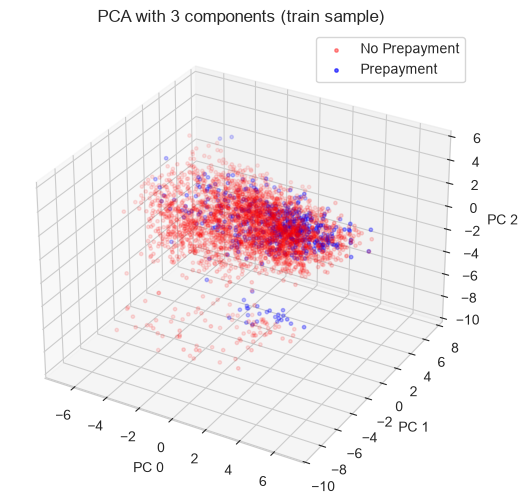

Explained variance ratio: [0.042 0.03  0.024]


In [14]:
n_vis = min(3000, len(Xtr))
idx = rng.choice(len(Xtr), n_vis, replace=False)
# make sure prepaid points are visible
pos_idx = np.where(ytr == 1)[0]
idx = np.unique(np.concatenate([idx, rng.choice(pos_idx, min(500, len(pos_idx)), replace=False)]))
pca = PCA(n_components=3).fit(Xtr[idx])
Z = pca.transform(Xtr[idx])
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
m0, m1 = ytr[idx] == 0, ytr[idx] == 1
ax.scatter(*Z[m0].T, c="red", s=6, alpha=0.4, label="No Prepayment")
ax.scatter(*Z[m1].T, c="blue", s=6, alpha=0.6, label="Prepayment")
ax.set_xlabel("PC 0"); ax.set_ylabel("PC 1"); ax.set_zlabel("PC 2")
ax.set_title("PCA with 3 components (train sample)")
ax.legend()
plt.savefig(FIG / "pca_3d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

## 9. Evaluation helpers

In [15]:
results = {}   # model name -> dict(y_true, y_pred, y_score)

def record(name, y_true, y_pred, y_score=None):
    results[name] = dict(y_true=np.asarray(y_true), y_pred=np.asarray(y_pred),
                         y_score=None if y_score is None else np.asarray(y_score))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    print(f"{name:22s} acc={(tn+tp)/len(y_true):.4%} | TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")

def summary_table():
    rows = []
    for name, r in results.items():
        yt, yp, ys = r["y_true"], r["y_pred"], r["y_score"]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows.append({
            "Model": name,
            "True No Prepay %": 100 * tn / max(tn + fp, 1),
            "False No Prepay %": 100 * fp / max(tn + fp, 1),
            "True Prepay %": 100 * tp / max(tp + fn, 1),
            "False Prepay %": 100 * fn / max(tp + fn, 1),
            "Overall Acc %": 100 * (tn + tp) / len(yt),
            "Precision": precision_score(yt, yp, zero_division=0),
            "F1": f1_score(yt, yp, zero_division=0),
            "ROC AUC": roc_auc_score(yt, ys) if ys is not None and len(np.unique(yt)) > 1 else np.nan,
            "PR AUC": average_precision_score(yt, ys) if ys is not None and len(np.unique(yt)) > 1 else np.nan,
        })
    return pd.DataFrame(rows).set_index("Model")

## 10. Logistic regression (baseline, L1, L2)

In [ ]:
t0 = time.time()
logit_models = {
    "Logistic (base)": LogisticRegression(C=1e6, solver="lbfgs", max_iter=3000),     # ~unregularised
    "Logistic (L1)":   LogisticRegression(penalty="l1", C=1.0, solver="liblinear", max_iter=1000),
    "Logistic (L2)":   LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=3000),
}
for name, mdl in logit_models.items():
    mdl.fit(Xtr, ytr)
    record(name, yte, mdl.predict(Xte), mdl.predict_proba(Xte)[:, 1])
print(f"({time.time()-t0:.0f}s)")
l1 = logit_models["Logistic (L1)"]
print("Features kept by L1:", int((l1.coef_ != 0).sum()), "of", Xtr.shape[1])

Logistic (base)        acc=99.9660% | TN=292,643 FP=61 FN=40 TP=4,284


In [ ]:
# Feature importance as in the paper: |coef| * mean(feature), with coefficients mapped back to raw feature units
coef_raw = l1.coef_[0] / scaler.scale_
imp = pd.DataFrame({
    "coef": coef_raw,
    "average": Xtr_raw_mean,
    "importance (paper)": np.abs(coef_raw) * np.abs(Xtr_raw_mean),
    "|std. coef|": np.abs(l1.coef_[0]),
}, index=feature_names)
print("Top 10 by paper's definition (scale-dependent):")
display(imp.sort_values("importance (paper)", ascending=False).head(10).round(4))
print("Top 10 by standardized |coefficient| (scale-free):")
display(imp.sort_values("|std. coef|", ascending=False).head(10).round(4))

## 11. Gaussian Discriminant Analysis (implemented from the equations)

In [ ]:
class GDA:
    # Class-conditional Gaussians N(mu_k, Sigma_k) with Bernoulli prior phi.
    # shared_cov=True -> linear boundary (LDA); False -> quadratic boundary (QDA).
    def __init__(self, shared_cov=False, reg=1e-3):
        self.shared_cov, self.reg = shared_cov, reg

    def fit(self, X, y):
        X = X.astype(np.float64)
        d = X.shape[1]
        self.log_prior = np.log(np.array([np.mean(y == 0), np.mean(y == 1)]))
        self.mu = [X[y == k].mean(axis=0) for k in (0, 1)]
        covs = [np.cov(X[y == k], rowvar=False) for k in (0, 1)]
        if self.shared_cov:
            pooled = sum((y == k).sum() * covs[k] for k in (0, 1)) / len(y)
            covs = [pooled, pooled]
        covs = [c + self.reg * np.eye(d) for c in covs]
        self.prec = [np.linalg.inv(c) for c in covs]
        self.logdet = [np.linalg.slogdet(c)[1] for c in covs]
        return self

    def _log_joint(self, X, k):
        diff = X - self.mu[k]
        maha = np.einsum("ij,ij->i", diff @ self.prec[k], diff)
        return -0.5 * maha - 0.5 * self.logdet[k] + self.log_prior[k]

    def decision_function(self, X, batch=200_000):
        out = []
        for i in range(0, len(X), batch):
            xb = X[i:i + batch].astype(np.float64)
            out.append(self._log_joint(xb, 1) - self._log_joint(xb, 0))
        return np.concatenate(out)

    def predict_proba(self, X):
        return 1.0 / (1.0 + np.exp(-np.clip(self.decision_function(X), -50, 50)))

    def predict(self, X):
        return (self.decision_function(X) > 0).astype(int)

for name, shared in [("GDA (linear)", True), ("GDA (quadratic)", False)]:
    g = GDA(shared_cov=shared, reg=GDA_REG).fit(Xtr, ytr)
    record(name, yte, g.predict(Xte), g.predict_proba(Xte))

## 12. Support Vector Machines (RBF / sigmoid / polynomial kernels)

Kernel SVMs are O(n^2)-O(n^3), so, as in the paper, they are trained on a small stratified subset (`SVM_TRAIN_SIZE`) and evaluated on a random subset of the test set (`SVM_TEST_SIZE`).

In [ ]:
if len(Xtr) > SVM_TRAIN_SIZE:
    Xs, _, ys, _ = train_test_split(Xtr, ytr, train_size=SVM_TRAIN_SIZE, stratify=ytr, random_state=SEED)
else:
    Xs, ys = Xtr, ytr
te_idx = rng.choice(len(Xte), min(SVM_TEST_SIZE, len(Xte)), replace=False)
Xte_s, yte_s = Xte[te_idx], yte[te_idx]
print("SVM train:", Xs.shape, "positives:", int(ys.sum()), "| SVM test:", Xte_s.shape, "positives:", int(yte_s.sum()))

for kernel in SVM_KERNELS:
    t0 = time.time()
    svm = SVC(kernel=kernel, C=1.0, gamma="scale", cache_size=1000, max_iter=300000)
    svm.fit(Xs, ys)
    record(f"SVM ({kernel})", yte_s, svm.predict(Xte_s), svm.decision_function(Xte_s))
    print(f"   fit+predict {time.time()-t0:.0f}s")

## 13. Feed-forward neural network (PyTorch)

Architecture (my reading of the paper): `Linear(n,128) -> BatchNorm -> ReLU -> Linear(128,256) -> BatchNorm -> Sigmoid -> Linear(256,1) -> sigmoid`, trained with SGD, lr 0.1 decayed by 0.91 per epoch for 30 epochs, binary cross-entropy with `pos_weight = 10`. The final sigmoid is folded into `BCEWithLogitsLoss`.

In [ ]:
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", dev)

class Net(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.Sigmoid(),
            nn.Linear(256, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)       # logits

def to_t(a, dtype=torch.float32): return torch.tensor(a, dtype=dtype, device=dev)
Xtr_t, ytr_t, Xva_t, yva_t = to_t(Xtr), to_t(ytr), to_t(Xva), to_t(yva)

model = Net(Xtr.shape[1]).to(dev)
opt = torch.optim.SGD(model.parameters(), lr=NN_LR, momentum=NN_MOMENTUM)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=NN_GAMMA)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(NN_POS_WEIGHT, device=dev))

@torch.no_grad()
def nn_predict_proba(X, batch=100_000):
    model.eval()
    out = []
    for i in range(0, len(X), batch):
        out.append(torch.sigmoid(model(to_t(X[i:i + batch]))).cpu().numpy())
    return np.concatenate(out)

history = []
for epoch in range(1, NN_EPOCHS + 1):
    model.train()
    perm = torch.randperm(len(Xtr_t), device=dev)
    tot, nb = 0.0, 0
    for i in range(0, len(perm), NN_BATCH):
        b = perm[i:i + NN_BATCH]
        if len(b) < 2:
            continue
        opt.zero_grad()
        loss = loss_fn(model(Xtr_t[b]), ytr_t[b])
        loss.backward()
        opt.step()
        tot += loss.item(); nb += 1
    sched.step()
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva_t), yva_t).item()
    history.append((epoch, tot / nb, val_loss))
    if epoch == 1 or epoch % 5 == 0 or epoch == NN_EPOCHS:
        print(f"epoch {epoch:2d} | train loss {tot/nb:.4f} | val loss {val_loss:.4f} | lr {sched.get_last_lr()[0]:.4f}")

p_te = nn_predict_proba(Xte)
record("Neural Network", yte, (p_te > 0.5).astype(int), p_te)

h = np.array(history)
plt.figure(figsize=(6, 3.5))
plt.plot(h[:, 0], h[:, 1], label="train"); plt.plot(h[:, 0], h[:, 2], label="validation")
plt.xlabel("epoch"); plt.ylabel("weighted BCE loss"); plt.legend(); plt.title("Neural network training")
plt.savefig(FIG / "nn_loss.png", dpi=150, bbox_inches="tight"); plt.show()

## 14. Results (paper Table 1 style)

In [ ]:
table = summary_table()
display(table.round(3))
table.round(5).to_csv(RES / f"results_{YEARS[0]}_{YEARS[-1]}_{TARGET_MODE}_{SPLIT_BY}.csv")

In [ ]:
names = list(results.keys())
ncols = 3
nrows = int(np.ceil(len(names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
for ax, name in zip(np.ravel(axes), names):
    r = results[name]
    cm = confusion_matrix(r["y_true"], r["y_pred"], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No prepay", "Prepay"], yticklabels=["No prepay", "Prepay"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for ax in np.ravel(axes)[len(names):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
for name, r in results.items():
    if r["y_score"] is None:
        continue
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_score"])
    pr, rc, _ = precision_recall_curve(r["y_true"], r["y_score"])
    a1.plot(fpr, tpr, label=name)
    a2.plot(rc, pr, label=name)
a1.plot([0, 1], [0, 1], "k--", lw=0.8)
a1.set_xlabel("False positive rate"); a1.set_ylabel("True positive rate"); a1.set_title("ROC")
a2.set_xlabel("Recall"); a2.set_ylabel("Precision"); a2.set_title("Precision-Recall")
a2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. How to change the run

| You want to... | Change |
|---|---|
| Use other years | `YEARS = list(range(2010, 2021))` (or any list, e.g. `[2015, 2019]`). Every year needs `raw/<year>/samp_orig_<year>.txt` and `samp_perf_<year>.txt`. |
| Run faster / lighter | Lower `LOANS_PER_QUARTER` (e.g. 500) and/or `SVM_TRAIN_SIZE`, `NN_EPOCHS`. |
| Use more data | Raise `LOANS_PER_QUARTER` (up to ~12,000 per quarter exists in the sample files). RAM is the limit: each loan-month row costs roughly 0.5 KB across the pandas frame + feature matrix. |
| Rebuild after changing years / sample size | Nothing - the cache file name contains years, sample size and seed. Delete `data/processed/*.pkl` to force a re-read. |
| Honest forecasting (no same-month leakage) | `TARGET_MODE = "next_month"` |
| Stop loans leaking across splits | `SPLIT_BY = "loan"` |

Notes for **many years (roughly 8+)**: the panel grows quickly because older loans have long histories (up to ~360 months). Reduce `LOANS_PER_QUARTER` (a drop to 100-300 reproduces the paper's setup) and keep the SVM subset small. For the full 22 years (1999-2020) with a large sample you would want to move the merge/feature steps to Polars/Parquet instead of pandas.

For **earlier years**, loans that mature within the window produce code `01` too; `MIN_REMAINING_MONTHS` is what separates maturity from prepayment. Macro data is downloaded for all dates automatically.